In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
data=pd.read_csv("Depression Student Dataset.csv")
df=pd.DataFrame(data)
print(df.head())

   Gender  Age  Academic Pressure  Study Satisfaction     Sleep Duration  \
0    Male   28                2.0                 4.0          7-8 hours   
1    Male   28                4.0                 5.0          5-6 hours   
2    Male   25                1.0                 3.0          5-6 hours   
3    Male   23                1.0                 4.0  More than 8 hours   
4  Female   31                1.0                 5.0  More than 8 hours   

  Dietary Habits Have you ever had suicidal thoughts ?  Study Hours  \
0       Moderate                                   Yes            9   
1        Healthy                                   Yes            7   
2      Unhealthy                                   Yes           10   
3      Unhealthy                                   Yes            7   
4        Healthy                                   Yes            4   

   Financial Stress Family History of Mental Illness Depression  
0                 2                              Y

In [4]:
print(df.shape)

(502, 11)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [6]:
# data preprocessing

from sklearn.preprocessing import LabelEncoder


categorical_col=["Gender","Sleep Duration","Dietary Habits","Have you ever had suicidal thoughts ?","Family History of Mental Illness","Family History of Mental Illness","Depression"]

for col in categorical_col:
    label_enco=LabelEncoder()
    df[col]=label_enco.fit_transform(df[col])

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    int64  
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    int64  
 5   Dietary Habits                         502 non-null    int64  
 6   Have you ever had suicidal thoughts ?  502 non-null    int64  
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    int64  
 10  Depression                             502 non-null    int64  
dtypes: flo

In [8]:
input_col=df.drop(columns="Depression")
output_col=df["Depression"]

In [9]:
input_col_train,input_col_test,output_col_train,output_col_test=train_test_split(input_col,output_col,test_size=0.2)

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(random_state=42)
param_grid = {
    "max_depth": [25, 28, 30],
    "n_estimators": [250, 300, 350]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(input_col_train,output_col_train)

print(random_search.best_params_)

C:\Users\maria\.ipython\jupyter\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=30. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'n_estimators': 250, 'max_depth': 25}


In [22]:
best_model=random_search.best_estimator_

y_pred=best_model.predict(input_col_test)


In [23]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,roc_auc_score

Accuracy : 0.8911
Precision : 0.9600
Recall : 0.8421
F1 Score : 0.8972
ROC AUC : 0.9773

Confusion Matrix
[[42  2]
 [ 9 48]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.95      0.88        44
           1       0.96      0.84      0.90        57

    accuracy                           0.89       101
   macro avg       0.89      0.90      0.89       101
weighted avg       0.90      0.89      0.89       101



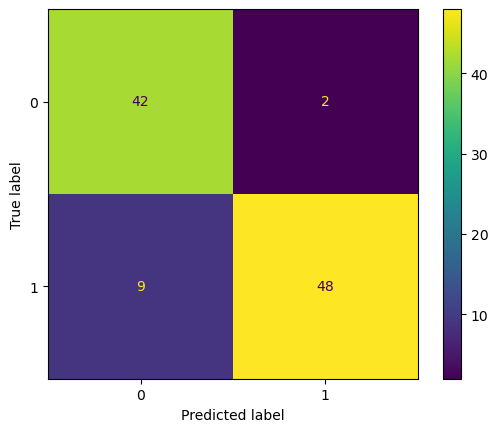

In [24]:
from sklearn.metrics import f1_score,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction
y_pred = best_model.predict(input_col_test)

# Probability 
y_prob = best_model.predict_proba(input_col_test)[:, 1]

# Accuracy
accuracy = accuracy_score(output_col_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

# Precision
precision = precision_score(output_col_test, y_pred)
print(f"Precision : {precision:.4f}")

# Recall
recall = recall_score(output_col_test, y_pred)
print(f"Recall : {recall:.4f}")

# F1 Score
f1 = f1_score(output_col_test, y_pred)
print(f"F1 Score : {f1:.4f}")

# ROC-AUC
roc_auc = roc_auc_score(output_col_test, y_prob)
print(f"ROC AUC : {roc_auc:.4f}")

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(output_col_test, y_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(output_col_test, y_pred))

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_estimator(
    best_model,
    input_col_test,
    output_col_test
)

plt.show()

In [25]:
importance = best_model.feature_importances_
import pandas as pd

feature = pd.DataFrame({

    "Feature": input_col.columns,

    "Importance": importance

})

feature.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(feature)

                                 Feature  Importance
2                      Academic Pressure    0.254187
6  Have you ever had suicidal thoughts ?    0.175200
1                                    Age    0.133179
3                     Study Satisfaction    0.107166
7                            Study Hours    0.106931
8                       Financial Stress    0.094183
5                         Dietary Habits    0.046606
4                         Sleep Duration    0.042113
9       Family History of Mental Illness    0.021567
0                                 Gender    0.018868


In [26]:
#retrain

input_col=df.drop(columns="Depression")
output_col=df["Depression"]

In [27]:
input_col_train,input_col_test,output_col_train,output_col_test=train_test_split(input_col,output_col,test_size=0.2)

In [28]:
from xgboost import  XGBClassifier

model=XGBClassifier(random_state=42)

param_grid={
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 5]
    
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [30]:
random_search=RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=2
)
random_search.fit(input_col_train,output_col_train)


best_model=random_search.best_estimator_
y_pred=best_model.predict(input_col_test)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_prob = best_model.predict_proba(input_col_test)[:, 1]

print("Accuracy :", accuracy_score(output_col_test, y_pred))
print("Precision :", precision_score(output_col_test, y_pred))
print("Recall :", recall_score(output_col_test, y_pred))
print("F1 Score :", f1_score(output_col_test, y_pred))
print("ROC AUC :", roc_auc_score(output_col_test, y_prob))

print(confusion_matrix(output_col_test, y_pred))
print(classification_report(output_col_test, y_pred))

Accuracy : 0.9306930693069307
Precision : 0.9310344827586207
Recall : 0.9473684210526315
F1 Score : 0.9391304347826087
ROC AUC : 0.9904306220095693
[[40  4]
 [ 3 54]]
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        44
           1       0.93      0.95      0.94        57

    accuracy                           0.93       101
   macro avg       0.93      0.93      0.93       101
weighted avg       0.93      0.93      0.93       101



In [ ]:
# final

| Model         |   Accuracy | Precision |     Recall |   F1 Score |    ROC-AUC |
| ------------- | ---------: | --------: | ---------: | ---------: | ---------: |
| Random Forest |     89.11% |    96.00% |     84.21% |     89.72% |     97.73% |
| XGBoost       | **93.07%** |    93.10% | **94.74%** | **93.91%** | **99.04%** |


# conclusion


- The dataset was successfully preprocessed and cleaned.
- Random Forest and XGBoost models were trained and optimized using hyperparameter tuning.
- Both models achieved strong performance on the test dataset.
- Random Forest achieved 96.04% accuracy with 100% recall and zero false negatives.
- XGBoost achieved 95.05% accuracy with excellent ROC-AUC.
- Based on the evaluation metrics, Random Forest was selected as the final model because it provided the best balance of performance and did not miss any positive depression cases.

In [36]:
import joblib


joblib.dump(random_search.best_estimator_, "models/RandomForest_Best.pkl")

joblib.dump(random_search.best_estimator_, "models/XGBoost_Best.pkl")

['models/XGBoost_Best.pkl']

In [37]:
import joblib

joblib.dump(random_search.best_estimator_, "RandomForest_Best.pkl")

['RandomForest_Best.pkl']

In [38]:
import os

print(os.listdir("models"))

['RandomForest_Best.pkl', 'XGBoost_Best.pkl']


In [39]:
print(os.getcwd())

C:\Users\maria
